In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import enrichmap as em
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import spearmanr, linregress, mannwhitneyu

In [4]:
sc.set_figure_params(frameon=False)
sc.settings._vector_friendly = False

In [5]:
# set working directory
# repository root (the folder containing `notebooks/`); safe to re-run this cell
project_dir = os.getcwd()
if os.path.basename(project_dir) == "notebooks":
    project_dir = os.path.dirname(project_dir)
project_dir += "/"
working_dir = project_dir + ""
os.chdir(working_dir)

# set figure directory
figure_dir = working_dir + "figures/"
os.makedirs(figure_dir, exist_ok=True)

# processed data directory
processed_data = working_dir + "processed_data/"
os.makedirs(processed_data, exist_ok=True)


In [6]:
adata = sc.read_h5ad(processed_data + "adata_slides_0_3.h5ad")

In [7]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

## HRD in Breast Cancer

In [8]:
df = pd.read_csv("signature_all_phenotypes.csv", index_col=0)

# Condition A: ground truth weights — positive and negative
hrd_gt = {
    k: v for k, v in df["HRD"].dropna().to_dict().items()
    if k in adata.var_names
}

# Condition B: positive weights only (upregulated in HRD)
hrd_pos = {
    k: v for k, v in df["HRD"].dropna().to_dict().items()
    if (k in adata.var_names) and (v > 0)
}

hrd_neg = {
    k: v for k, v in df["HRD"].dropna().to_dict().items()
    if (k in adata.var_names) and (v < 0)
}

sig_type = "hrd"

n_pos = sum(v > 0 for v in hrd_gt.values())
n_neg = sum(v < 0 for v in hrd_gt.values())
print(f"Ground truth  — {sig_type}: {len(hrd_gt)} genes ({n_pos} positive, {n_neg} negative)")
print(f"Positive only — {sig_type}: {len(hrd_pos)} genes")
print(f"Negative only — {sig_type}: {len(hrd_neg)} genes")

Ground truth  — hrd: 219 genes (124 positive, 95 negative)
Positive only — hrd: 124 genes
Negative only — hrd: 95 genes


### Condition A — Ground Truth Weights (+/−)

Signal genes scored with their true weights, including both positive and negative contributions.

In [9]:
gt_dict = {"hrd_gt": hrd_gt}
em.tl.score(adata, gene_weights=gt_dict, batch_key="batch")


  0%|          | 0/1 [00:00<?, ?it/s]


Scoring hrd_gt: 219/219 genes found:   0%|          | 0/1 [00:00<?, ?it/s]


Scoring hrd_gt: 219/219 genes found: 100%|██████████| 1/1 [00:27<00:00, 27.12s/it]


Scoring hrd_gt: 219/219 genes found: 100%|██████████| 1/1 [00:27<00:00, 27.12s/it]

### Condition B — Positive Weights Only

Same signatures filtered to genes with positive weights; negative contributions are discarded.

In [10]:
pos_dict = {"hrd_pos": hrd_pos}
em.tl.score(adata, gene_weights=pos_dict, batch_key="batch")


  0%|          | 0/1 [00:00<?, ?it/s]


Scoring hrd_pos: 124/124 genes found:   0%|          | 0/1 [00:00<?, ?it/s]


Scoring hrd_pos: 124/124 genes found: 100%|██████████| 1/1 [00:15<00:00, 15.75s/it]


Scoring hrd_pos: 124/124 genes found: 100%|██████████| 1/1 [00:15<00:00, 15.75s/it]

### Condition C — Inferred Weights

Gene list from Condition B (positive-weight genes); EnrichMap infers weights via CV without access to the true weights.

In [11]:
inferred_dict = {"hrd_inferred": list(hrd_pos.keys())}
em.tl.score(adata, gene_set=inferred_dict, batch_key="batch")


  0%|          | 0/1 [00:00<?, ?it/s]


Scoring hrd_inferred: 124/124 genes found:   0%|          | 0/1 [00:00<?, ?it/s]


Scoring hrd_inferred: 124/124 genes found: 100%|██████████| 1/1 [00:16<00:00, 16.00s/it]


Scoring hrd_inferred: 124/124 genes found: 100%|██████████| 1/1 [00:16<00:00, 16.01s/it]

### Condition D — Signed Inferred Weights

Weights inferred with their signs.

In [12]:
inferred_signed_dict = em.tl.build_signed_weights(adata, up_genes=list(hrd_pos.keys()), down_genes=list(hrd_neg.keys()), score_key="hrd_inferred_signed")
em.tl.score(adata, gene_weights=inferred_signed_dict, batch_key="batch")


  0%|          | 0/1 [00:00<?, ?it/s]


Scoring hrd_inferred_signed: 219/219 genes found:   0%|          | 0/1 [00:00<?, ?it/s]


Scoring hrd_inferred_signed: 219/219 genes found: 100%|██████████| 1/1 [00:26<00:00, 26.76s/it]


Scoring hrd_inferred_signed: 219/219 genes found: 100%|██████████| 1/1 [00:26<00:00, 26.76s/it]

In [13]:
CONDITIONS = [
    {"key": "gt",       "label": "Ground truth (+/−)", "col_suffix": "gt_score"},
    {"key": "pos",      "label": "Positive weights",   "col_suffix": "pos_score"},
    {"key": "inferred", "label": "Inferred weights",   "col_suffix": "inferred_score"},
    {"key": "inferred_signed", "label": "Inferred signed weights", "col_suffix": "inferred_signed_score"},
]

CONDITION_COLORS = {
    "gt":       "#6D4AFF",
    "pos":      "#A792FF",
    "inferred": "#8D8D8D",
    "inferred_signed": "#FF6B6B"
}

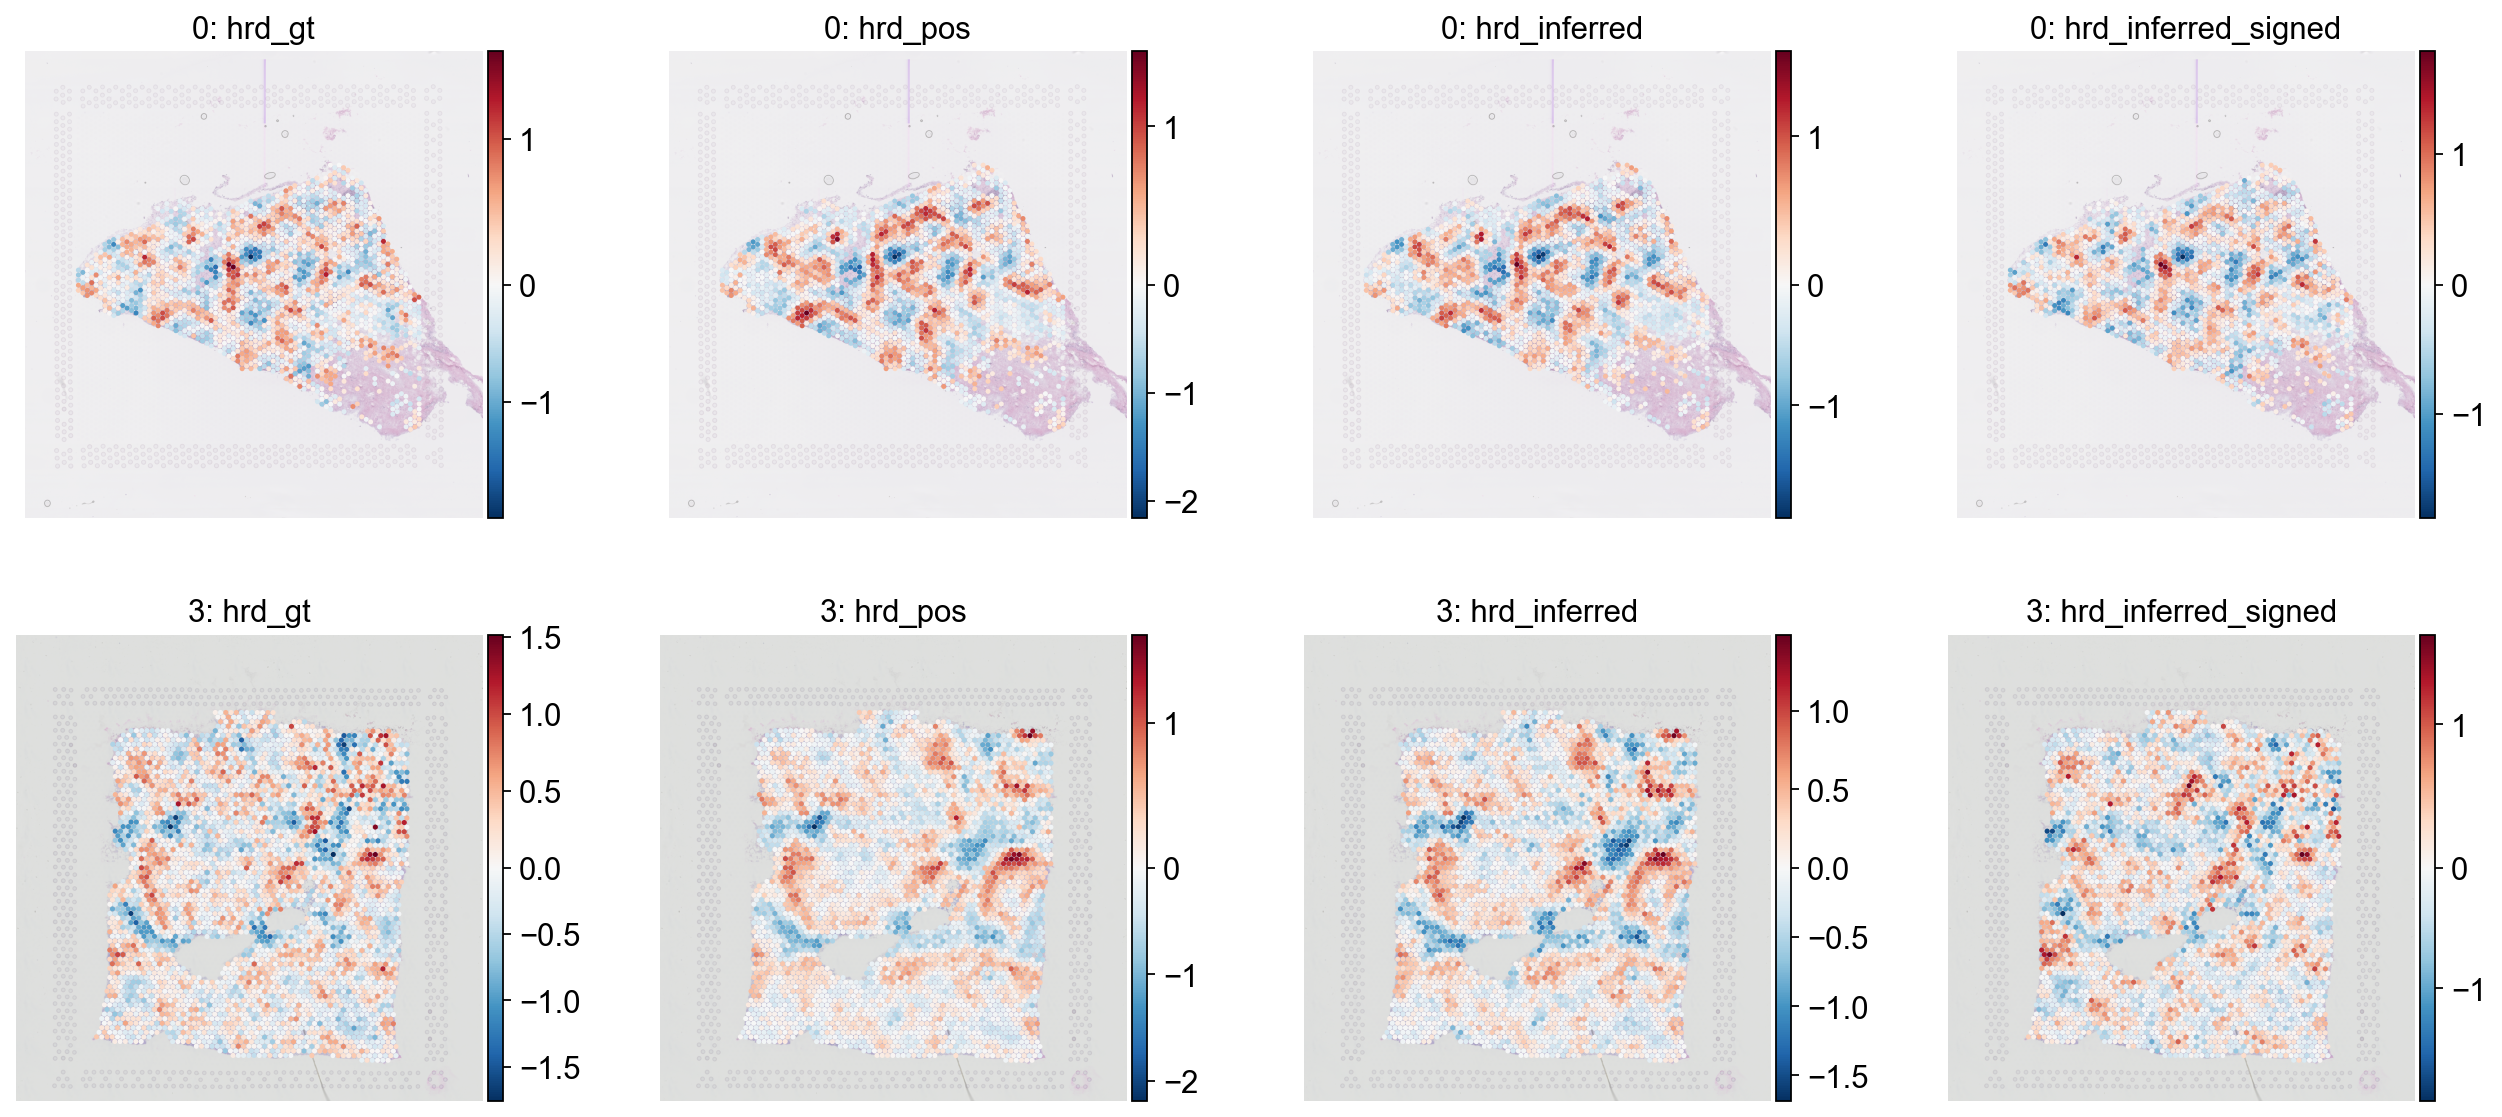

In [14]:
em.pl.spatial_enrichmap(
    adata,
    score_key=[f"{sig_type}_{c['col_suffix']}" for c in CONDITIONS],
    size=1.5,
    library_key="batch",
    ncols=4,
    cmap="RdBu_r",
    save="breast_HRD_spatial_enrichmap_conditions.pdf",
)

## Ground Truth vs Positive-Only vs Inferred — Per-spot Correlation

Per-spot correlation of each condition against the ground-truth (+/−) score. Agreement confirms whether discarding negative weights or inferring weights recovers the full-weight signal.

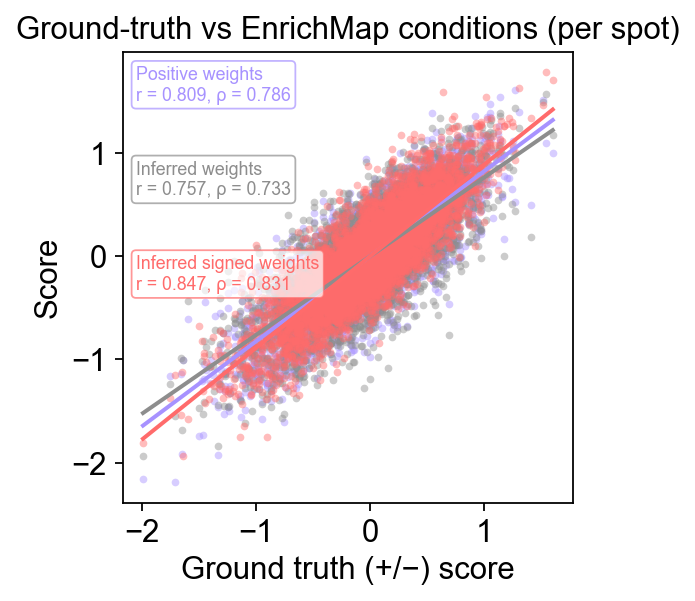

In [15]:
comparison_conditions = [
    ("pos_score",             "Positive weights",        CONDITION_COLORS["pos"]),
    ("inferred_score",        "Inferred weights",        CONDITION_COLORS["inferred"]),
    ("inferred_signed_score", "Inferred signed weights", CONDITION_COLORS["inferred_signed"]),
]

fig, ax = plt.subplots(figsize=(4, 4))

gt_col = f"{sig_type}_gt_score"
x = adata.obs[gt_col].values
x_range = np.linspace(x.min(), x.max(), 100)
y_positions = [0.97, 0.76, 0.55]

for (cond_suffix, cond_label, color), y_pos in zip(comparison_conditions, y_positions):
    y = adata.obs[f"{sig_type}_{cond_suffix}"].values
    ax.scatter(x, y, c=color, s=12, alpha=0.45, linewidths=0)
    slope, intercept, *_ = linregress(x, y)
    ax.plot(x_range, slope * x_range + intercept,
            color=color, linewidth=1.8, linestyle="-")
    r_pear = pd.Series(x).corr(pd.Series(y))
    r_sp, _ = spearmanr(x, y)
    ax.text(
        0.03, y_pos,
        f"{cond_label}\nr = {r_pear:.3f}, \u03c1 = {r_sp:.3f}",
        transform=ax.transAxes, va="top", fontsize=8, color=color,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.7,
                  edgecolor=color, linewidth=0.8),
    )

ax.set_box_aspect(1)
ax.set_xlabel("Ground truth (+/\u2212) score")
ax.set_ylabel("Score")
ax.grid(False)
plt.title("Ground-truth vs EnrichMap conditions (per spot)")
plt.tight_layout()
plt.savefig(f"{figure_dir}09_HRD_hexbin_correlations.pdf", bbox_inches="tight") if os.path.isdir(figure_dir) else None
plt.show()

## Steiger Z-test

Tests whether positive-only or inferred weights correlate **significantly more strongly** with the ground-truth (+/−) score, accounting for the shared reference variable.

In [16]:
def steiger_z(r12, r13, r23, n):
    r_bar = (r12 + r13) / 2
    f = (1 - r23) / (2 * (1 - r_bar**2))
    h = (1 - f * r_bar**2) / (1 - r_bar**2)
    z1, z2 = np.arctanh(r12), np.arctanh(r13)
    Z = (z1 - z2) * np.sqrt((n - 3) / (2 * (1 - r23) * h))
    p = 2 * (1 - stats.norm.cdf(abs(Z)))
    return Z, p


obs = adata.obs
st  = sig_type
r_pos    = obs[f"{st}_gt_score"].corr(obs[f"{st}_pos_score"])
r_inf    = obs[f"{st}_gt_score"].corr(obs[f"{st}_inferred_score"])
r_signed = obs[f"{st}_gt_score"].corr(obs[f"{st}_inferred_signed_score"])

print("Pearson r with ground truth:")
print(f"  Positive weights:        {r_pos:.4f}")
print(f"  Inferred weights:        {r_inf:.4f}")
print(f"  Inferred signed weights: {r_signed:.4f}")
print()

pairwise = [
    ("Positive", "Inferred",
     r_pos, r_inf,    obs[f"{st}_pos_score"].corr(obs[f"{st}_inferred_score"])),
    ("Positive", "Inferred signed",
     r_pos, r_signed, obs[f"{st}_pos_score"].corr(obs[f"{st}_inferred_signed_score"])),
    ("Inferred", "Inferred signed",
     r_inf, r_signed, obs[f"{st}_inferred_score"].corr(obs[f"{st}_inferred_signed_score"])),
]

print(f"{'Comparison':<32} {'Steiger Z':>12} {'p':>12}")
print("-" * 58)
for label_a, label_b, r12, r13, r23 in pairwise:
    Z, p = steiger_z(r12, r13, r23, n=len(obs))
    print(f"{label_a + ' vs ' + label_b:<32} {Z:>12.3f} {p:>12.2e}")


Pearson r with ground truth:
  Positive weights:        0.8088
  Inferred weights:        0.7567
  Inferred signed weights: 0.8471

Comparison                          Steiger Z            p
----------------------------------------------------------
Positive vs Inferred                   20.933     0.00e+00
Positive vs Inferred signed            -7.854     4.00e-15
Inferred vs Inferred signed           -17.025     0.00e+00


## Bootstrapped Spearman Correlations

Bootstrap distributions (n=1,000) of Spearman ρ with the ground-truth (+/−) score. The Mann-Whitney bracket tests whether positive-only and inferred weights differ significantly in their agreement with the ground truth.

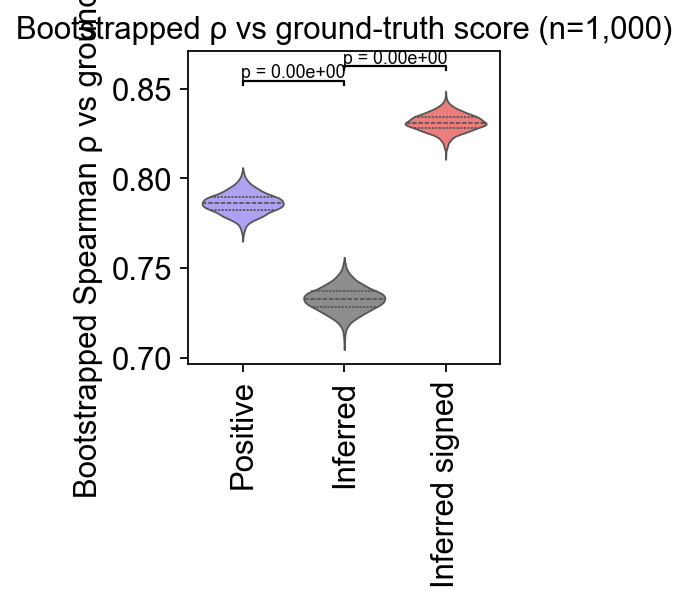

In [17]:
def bootstrap_spearman(x, y, n_boot=1000, seed=0):
    rng_b = np.random.default_rng(seed)
    n = len(x)
    corrs = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng_b.integers(0, n, size=n)
        corrs[b] = spearmanr(x[idx], y[idx]).statistic
    return corrs


boot_records = []
gt_col = f"{sig_type}_gt_score"
for cond_suffix, cond_label in [
    ("pos_score",             "Positive"),
    ("inferred_score",        "Inferred"),
    ("inferred_signed_score", "Inferred signed"),
]:
    boots = bootstrap_spearman(
        adata.obs[gt_col].values,
        adata.obs[f"{sig_type}_{cond_suffix}"].values,
    )
    for val in boots:
        boot_records.append({"condition": cond_label, "rho": val})

boot_df = pd.DataFrame(boot_records)
order   = ["Positive", "Inferred", "Inferred signed"]
palette = [CONDITION_COLORS["pos"], CONDITION_COLORS["inferred"], CONDITION_COLORS["inferred_signed"]]

fig, ax = plt.subplots(figsize=(4, 4))
sns.violinplot(
    data=boot_df, x="condition", y="rho",
    order=order, palette=palette,
    inner="quart", ax=ax, linewidth=0.8,
)

y_max  = boot_df["rho"].max()
y_step = (boot_df["rho"].max() - boot_df["rho"].min()) * 0.06
for i, (c1, c2) in enumerate([(0, 1), (1, 2)]):
    g1 = boot_df.loc[boot_df["condition"] == order[c1], "rho"].values
    g2 = boot_df.loc[boot_df["condition"] == order[c2], "rho"].values
    _, p = mannwhitneyu(g1, g2, alternative="two-sided")
    y_bar = y_max + y_step * (i + 1)
    ax.plot([c1, c1, c2, c2], [y_bar - y_step * 0.3, y_bar, y_bar, y_bar - y_step * 0.3],
            color="black", linewidth=1)
    ax.text((c1 + c2) / 2, y_bar + y_step * 0.2, f"p = {p:.2e}", ha="center", fontsize=8)

ax.set_box_aspect(1)
ax.set_xlabel("")
ax.set_ylabel("Bootstrapped Spearman \u03c1 vs ground truth")
ax.tick_params(axis="x", rotation=90)
ax.grid(False)
plt.title("Bootstrapped \u03c1 vs ground-truth score (n=1,000)")
plt.tight_layout()
plt.savefig(f"{figure_dir}09_HRD_bootstrap_correlation.pdf", bbox_inches='tight') if os.path.isdir(figure_dir) else None
plt.show()

## Comparison with Other Methods

AUCell, Scanpy, ssGSEA, GSVA, and Z-score each receive the same positive-weight gene list (Condition B/C). Per-spot scores are compared against the ground-truth (+/−) score to assess how well each method recovers the full-weight signal.

In [18]:
from score_signatures import score_signatures

benchmark_sigs = {sig_type: list(hrd_pos.keys())}

adata = score_signatures(
    adata,
    signatures_dict=benchmark_sigs,
    methods=["aucell", "scanpy", "ssgsea", "gsva", "zscore"],
)

bench_cols = [c for c in adata.obs.columns
              if any(c.endswith(f"_{m}") for m in ["aucell", "scanpy", "ssgsea", "gsva", "zscore"])]
print(f"{len(bench_cols)} benchmark score columns added:")
for c in sorted(bench_cols):
    print(f"  {c}")

5 benchmark score columns added:
  hrd_aucell
  hrd_gsva
  hrd_scanpy
  hrd_ssgsea
  hrd_zscore


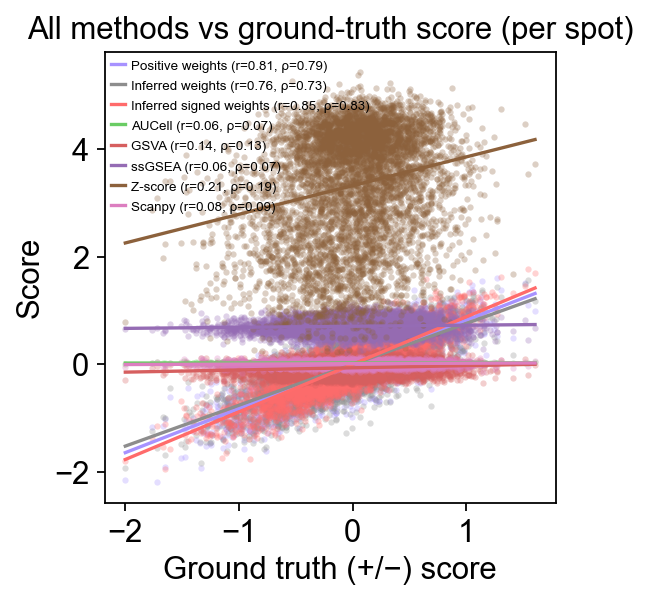

In [19]:
BENCH_METHODS = [
    {"key": "aucell",  "label": "AUCell",   "color": "#6ACC64"},
    {"key": "gsva",    "label": "GSVA",      "color": "#D65F5F"},
    {"key": "ssgsea",  "label": "ssGSEA",    "color": "#956CB4"},
    {"key": "zscore",  "label": "Z-score",   "color": "#8C613C"},
    {"key": "scanpy",  "label": "Scanpy",    "color": "#DC7EC0"},
]

all_conditions = [
    ("pos_score",             "Positive weights",        CONDITION_COLORS["pos"]),
    ("inferred_score",        "Inferred weights",        CONDITION_COLORS["inferred"]),
    ("inferred_signed_score", "Inferred signed weights", CONDITION_COLORS["inferred_signed"]),
] + [(m["key"], m["label"], m["color"]) for m in BENCH_METHODS]

fig, ax = plt.subplots(figsize=(4, 4))

gt_col = f"{sig_type}_gt_score"
x = adata.obs[gt_col].values
x_range = np.linspace(x.min(), x.max(), 100)

for cond_suffix, cond_label, color in all_conditions:
    col = f"{sig_type}_{cond_suffix}"
    if col not in adata.obs.columns:
        continue
    y = adata.obs[col].values
    r_pear = pd.Series(x).corr(pd.Series(y))
    r_sp, _ = spearmanr(x, y)
    slope, intercept, *_ = linregress(x, y)
    ax.scatter(x, y, c=color, s=8, alpha=0.3, linewidths=0)
    ax.plot(
        x_range, slope * x_range + intercept,
        color=color, linewidth=1.5, linestyle="-",
        label=f"{cond_label} (r={r_pear:.2f}, \u03c1={r_sp:.2f})",
    )

ax.set_box_aspect(1)
ax.set_xlabel("Ground truth (+/\u2212) score")
ax.set_ylabel("Score")
ax.grid(False)
ax.legend(fontsize=6, loc="upper left")
plt.title("All methods vs ground-truth score (per spot)")
plt.tight_layout()
plt.savefig(f"{figure_dir}09_HRD_all_methods_correlation.pdf", bbox_inches="tight") if os.path.isdir(figure_dir) else None
plt.show()

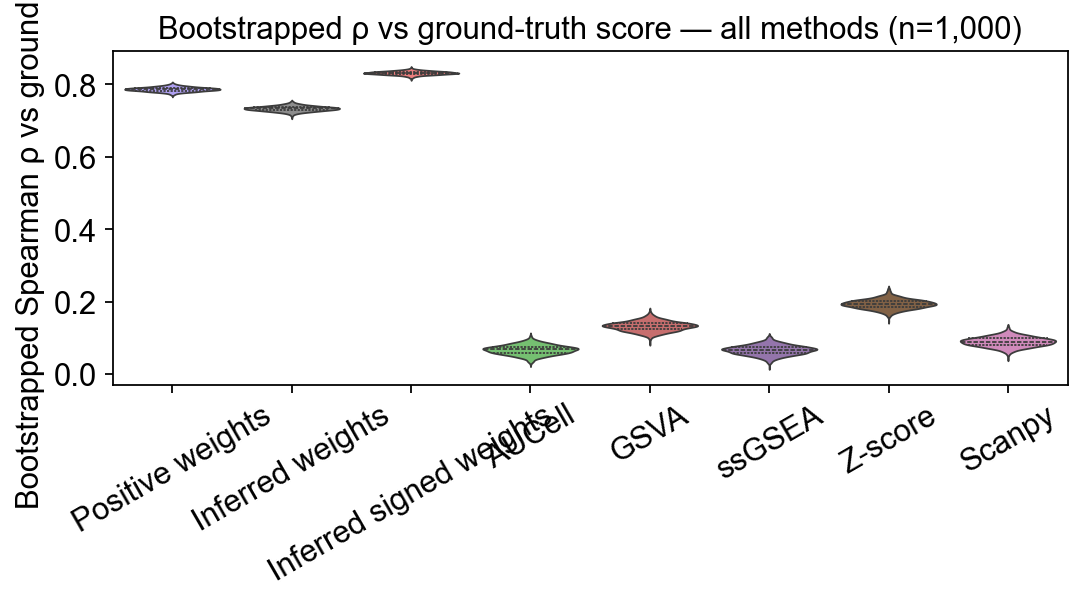

In [20]:
boot_all_records = []
gt_col = f"{sig_type}_gt_score"
for cond_suffix, cond_label, _ in all_conditions:
    col = f"{sig_type}_{cond_suffix}"
    if col not in adata.obs.columns:
        continue
    boots = bootstrap_spearman(
        adata.obs[gt_col].values,
        adata.obs[col].values,
    )
    for val in boots:
        boot_all_records.append({"condition": cond_label, "rho": val})

boot_all_df = pd.DataFrame(boot_all_records)
method_order  = [lbl for _, lbl, _ in all_conditions]
method_colors = {lbl: col for _, lbl, col in all_conditions}
order   = [m for m in method_order if m in boot_all_df["condition"].unique()]
palette = [method_colors[m] for m in order]

fig, ax = plt.subplots(figsize=(7, 4))
sns.violinplot(
    data=boot_all_df, x="condition", y="rho",
    order=order, palette=palette,
    inner="quart", ax=ax, linewidth=0.8,
)
ax.set_xlabel("")
ax.set_ylabel("Bootstrapped Spearman \u03c1 vs ground truth")
ax.tick_params(axis="x", rotation=30)
ax.grid(False)
plt.title("Bootstrapped \u03c1 vs ground-truth score \u2014 all methods (n=1,000)")
plt.tight_layout()
plt.savefig(f"{figure_dir}09_HRD_all_methods_bootstrap.pdf", bbox_inches="tight") if os.path.isdir(figure_dir) else None
plt.show()

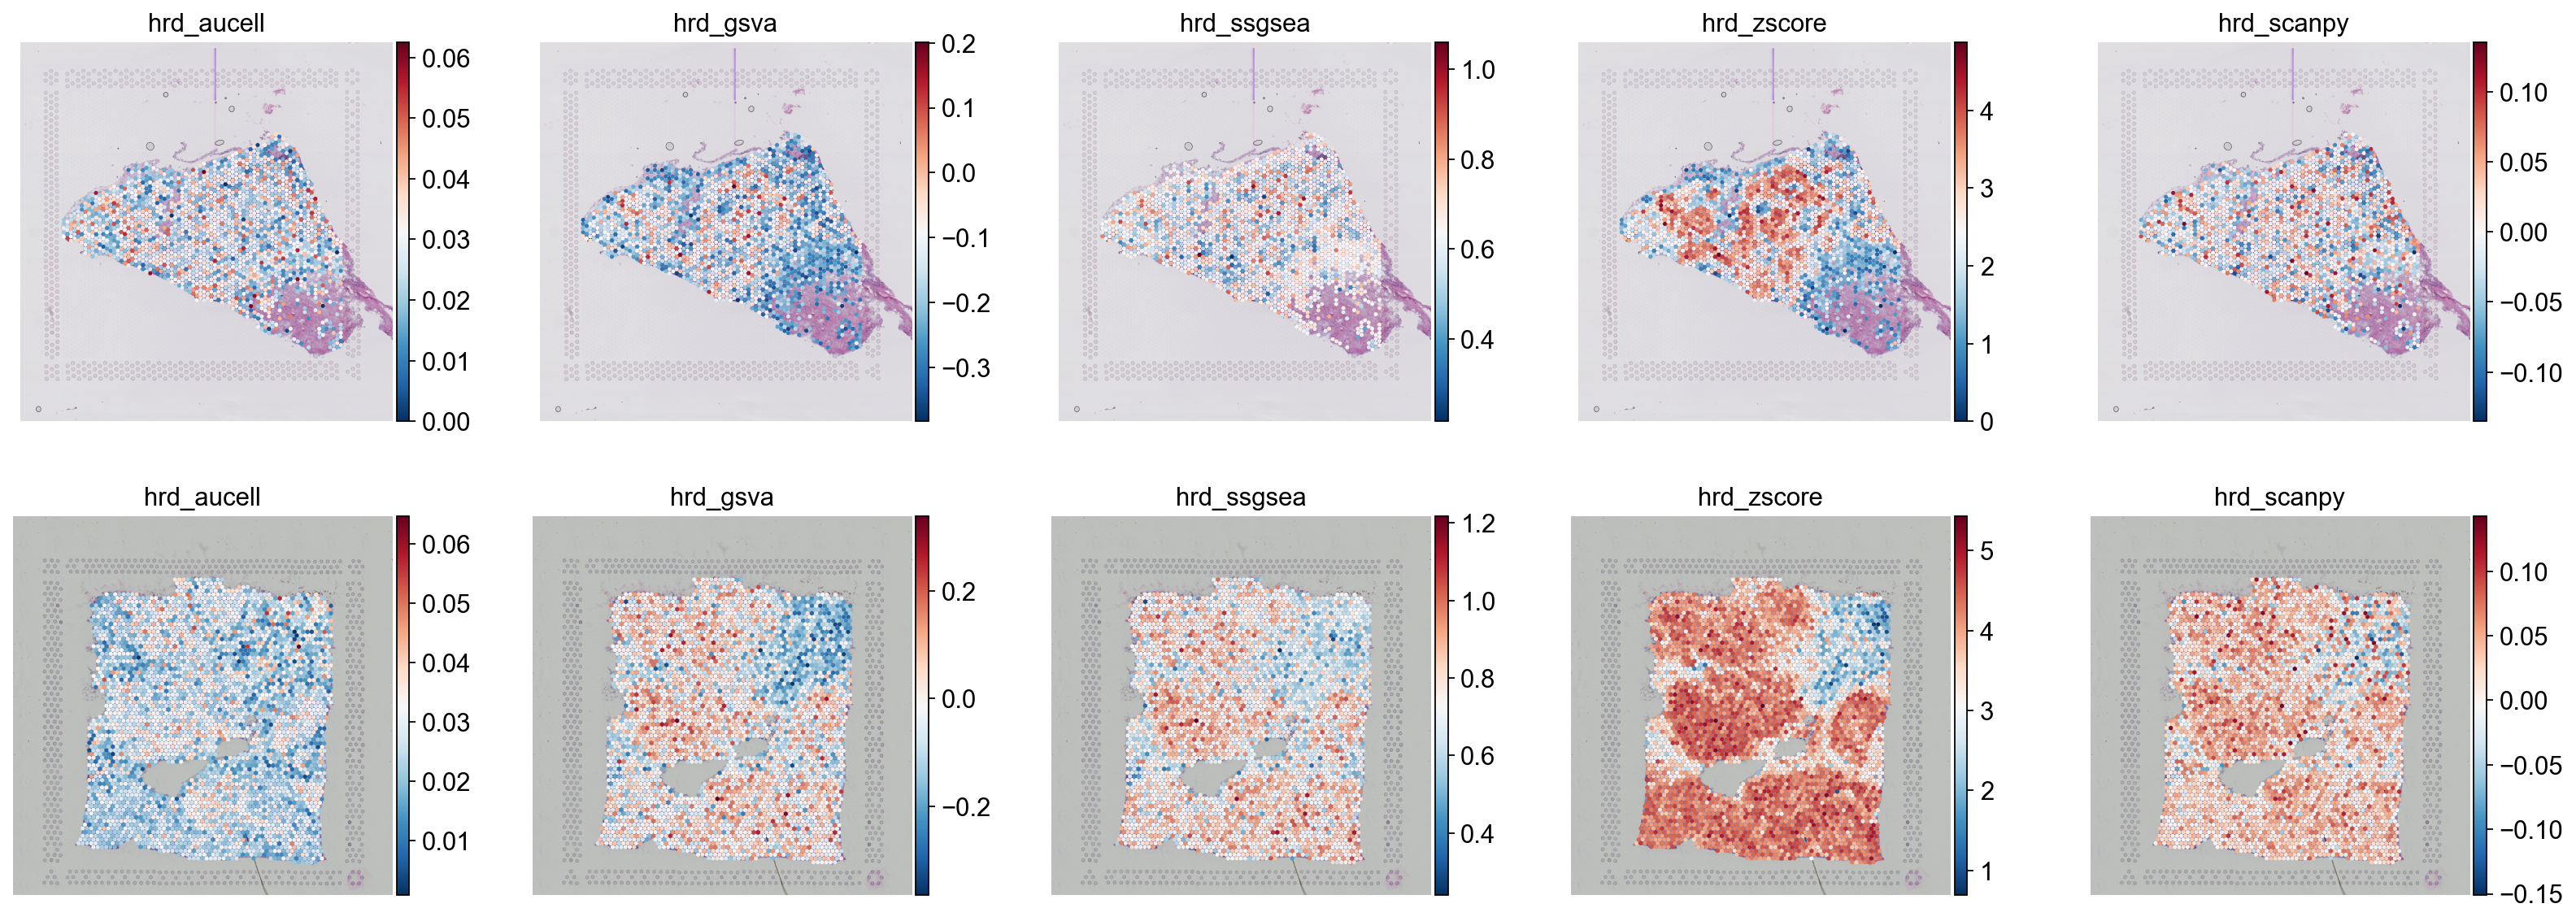

In [21]:
sq.pl.spatial_scatter(
    adata,
    color=[f"{sig_type}_{m['key']}" for m in BENCH_METHODS if f"{sig_type}_{m['key']}" in adata.obs.columns],
    library_key="batch",
    library_id=["0", "3"],
    size=1.5,
    ncols=5,
    cmap="RdBu_r",
    save="breast_HRD_benchmark_methods_spatial_scatter.pdf",
)